# Environment-Induced Entanglement: Markov vs OU Memory

## Introduction & Problem Statement
Two initially separable single-mode squeezed states coupled to a common reservoir via collective dissipation are studied. Symmetric structure results in a decoherence free subspace (DFS) which preserves any initial non-classical resource (i.e., squeezing) originally mapped to the subspace. This is true in Markovian and OU environments. 
Question: How does environemntal memory and tuning modify entanglement onset and steady-state behavior

### This notebook reproduces representative dynamics from ongoing research by A. Couvertier and T. Yu, currently under review. The full analysis, parameter studies, and theoretical results are not included here. 
*A. Couvertier and T. Yu, “Environment-Generated Entanglement Dynamics of Separable Squeezed States in Finite Memory Structured Reservoir,” manuscript under review at Physical Review A (2026)*

# System Construction (Markovian Baseline)

In [1]:
import sys
sys.path.append("../../src")
import numpy as np

In [14]:
from gaussian_systems.systems import GaussianCVSystem, single_pole_ou_embedding
n = 2 # initialize 2 CV modes
kappa = 1 # normalize all results against environmental decay
delta_2 = 0.0*kappa # assume resonance for the symmetry argument
# THIS ASSUMES A ROTATED FRAME WITH RESPECT TO MODE 1
frequencies = np.array([0.0, delta_2]) # mode 1 will have a frequency of 0 and mode 2 a frequency of delta_2. 

base_system = GaussianCVSystem.free_evolution(n,frequencies) # a system with only self-energy terms

# update system to have a Markovian environmental coupling of the form L = sqrt(kappa)*(a_1 + a_2)
markov_system = base_system.copy_system().multi_annihilation_dissipator((1,2), kappa)

# State Construction (Markovian Baseline)

In [15]:
from gaussian_systems.initial_state import GaussianCVState
base_state = GaussianCVState.vacuum(n)

#STATE PARAMETERS

# squeezing values r_1 and r_2 are tuples such that (|r_i|, phase_i)
r1, r2 = ( (1.0,0.0), (1.0,0.0) ) 

# displacement values d_i such that np.isinstance(d_i,numbers.Complex) 
d1, d2 = ( (1/np.sqrt(2))*(3+3j), (1/np.sqrt(2))*(-3-3j))

base_state.single_mode_squeeze(r1,1)
base_state.single_mode_squeeze(r2,2)
base_state.single_mode_displacement(d1,1)
base_state.single_mode_displacement(d2,2)

# Markovian Simulation

In [16]:
t_eval = np.linspace(0, 50, 800)

sol_markov = markov_system.evolve_state(base_state, t_eval)

ent_markov = sol_markov.entanglement_time_trace((1,2))
pur_markov = sol_markov.purity_time_trace((1,2))

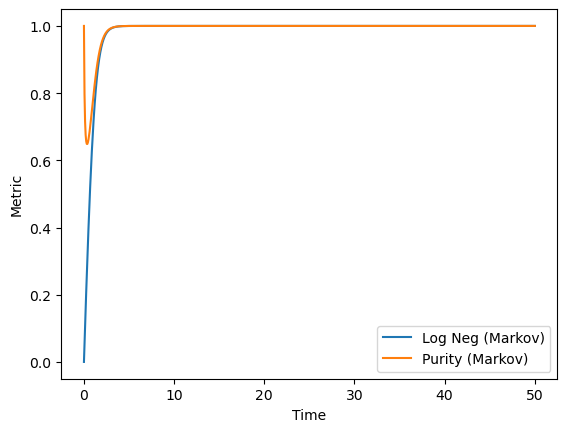

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(t_eval, ent_markov, label="Log Neg (Markov)")
ax.plot(t_eval, pur_markov, label="Purity (Markov)")
ax.set_xlabel("Time")
ax.set_ylabel("Metric")
ax.legend()

# OU Embedding (Updating base_system and base_state)

In [26]:
# A single-pole OU memory kernel is defined by a memory rate (gamma) and central frequency (omega). In the rotated
# frame is the central frequency is replaced by an environment detuning (delta_E)
gamma = 0.5*kappa
delta_E = 2.0*kappa

ou_state, ou_system = single_pole_ou_embedding(
    state=base_state, 
    system=base_system,
    subsystem=(1,2),
    coupling_types=("annihilation","annihilation"),
    memory_rate=gamma,
    env_freq=delta_E,
    decay_rate=kappa
)

In [27]:
# Solutions are found in the same format as the Markvov case
sol_ou = ou_system.evolve_state(ou_state, t_eval)

ent_ou = sol_ou.entanglement_time_trace((1,2))
pur_ou = sol_ou.purity_time_trace((1,2))

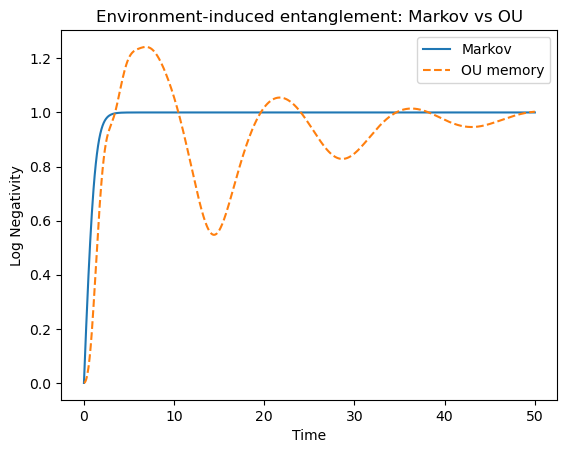

In [28]:
fig, ax = plt.subplots()

ax.plot(t_eval, ent_markov, label="Markov")
ax.plot(t_eval, ent_ou, linestyle="--", label="OU memory")

ax.set_xlabel("Time")
ax.set_ylabel("Log Negativity")
ax.set_title("Environment-induced entanglement: Markov vs OU")
ax.legend()

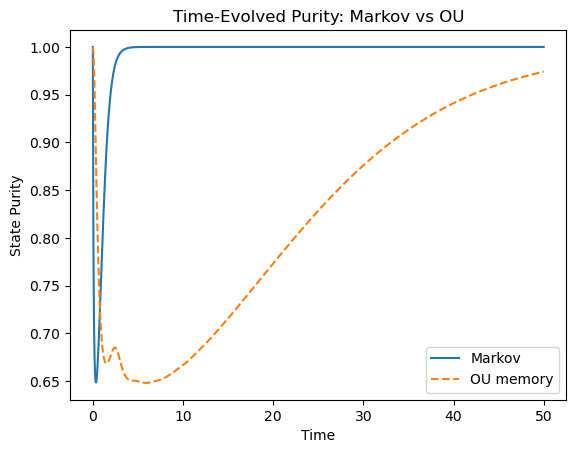

In [29]:
fig, ax = plt.subplots()

ax.plot(t_eval, pur_markov, label="Markov")
ax.plot(t_eval, pur_ou, linestyle="--", label="OU memory")

ax.set_xlabel("Time")
ax.set_ylabel("State Purity")
ax.set_title("Time-Evolved Purity: Markov vs OU")
ax.legend()